# Customer Churn Analysis: Why Are We Losing Customers?
### VortexTech Data Science & Analytics Internship — Week 4 Capstone

**Dataset:** Telco Customer Churn (7,043 customers of a telecom provider), covering account details, services subscribed, billing information, and whether the customer churned (cancelled service).

**Central question:** *Why are customers churning, and what could the business do to reduce it?*


## Executive Summary

We looked at data from **7,043 customers** of a telecom company to understand why roughly **1 in 4 customers (26.5%)** cancel their service, and what the business could do about it.

The single biggest factor is **contract type**. Customers on flexible, month-to-month plans cancel **15 times more often** than customers locked into two-year contracts. This effect compounds with how new the customer is: nearly **half of customers leave within their first year**, but that risk drops to under 7% once someone has stayed five years or more — loyalty builds quickly if we can keep customers past the danger zone.

We also found that the type of internet service matters a lot. Customers with **fiber optic internet churn more than twice as often** as customers with basic DSL service, which suggests a pricing or reliability problem with the fiber product rather than a demand problem. Separately, customers who don't have **add-on protections like tech support or online security** cancel at close to **three times the rate** of customers who do — these add-ons seem to build stickiness, not just generate extra revenue. Finally, customers who pay by **manual electronic check** churn far more often than those on automatic payment methods, which is often a sign of lower commitment or friction in the billing process.

None of these patterns are about customers being unhappy with the core service everywhere — they're about **specific, fixable friction points**: contract flexibility, the first-year experience, the fiber product, missing add-ons, and manual billing. The recommendations below target exactly these points.


## Methodology (Brief)

- **Data source:** Telco Customer Churn dataset, 7,043 customer records, 21 columns (demographics, account info, services subscribed, billing, and churn status).
- **Cleaning:** Converted `TotalCharges` from text to numeric (11 blank values, all brand-new customers with 0 months of tenure, were set to 0). Checked for duplicate records (none found) and confirmed all other columns had no missing values.
- **Analysis approach:** Calculated the overall churn rate, then broke it down across contract type, tenure, internet service type, add-on services, payment method, and billing amount to find where churn concentrates.
- **Tools:** Python (pandas for analysis, matplotlib/seaborn for visualization).

*Full cleaning and analysis code is available in the Appendix at the end of this notebook for technical readers.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
COLOR_CHURN = '#E4572E'
COLOR_STAY = '#2E86AB'
PALETTE = [COLOR_CHURN, COLOR_STAY, '#76B041', '#F3A712', '#7A5195']

df = pd.read_csv('Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

bins = [0, 12, 24, 48, 60, 100]
labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-60 mo', '61+ mo']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

overall_churn = df['Churn_flag'].mean()
print(f"Dataset ready: {df.shape[0]} customers, overall churn rate {overall_churn:.1%}")

Dataset ready: 7043 customers, overall churn rate 26.5%


## Key Findings

### Finding 1 — Contract length is the strongest predictor of churn

Customers on **month-to-month contracts churn at 42.7%**, compared to **11.3%** for one-year contracts and just **2.8%** for two-year contracts. Locking customers into longer commitments is strongly associated with retention.

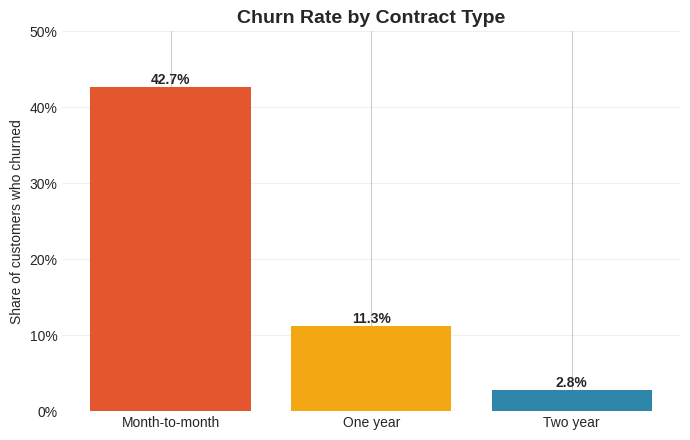

In [2]:
contract_churn = df.groupby('Contract')['Churn_flag'].mean().reindex(
    ['Month-to-month', 'One year', 'Two year'])

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(contract_churn.index, contract_churn.values, color=[COLOR_CHURN, '#F3A712', COLOR_STAY])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of customers who churned')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Finding 2 — The first year is the danger zone

Churn risk falls off sharply the longer a customer stays. Customers in their **first 12 months churn at 47.4%**, but that falls to **6.6%** for customers who have been with the company for 5+ years. If a customer can be retained past year one, they are increasingly likely to stay for good.

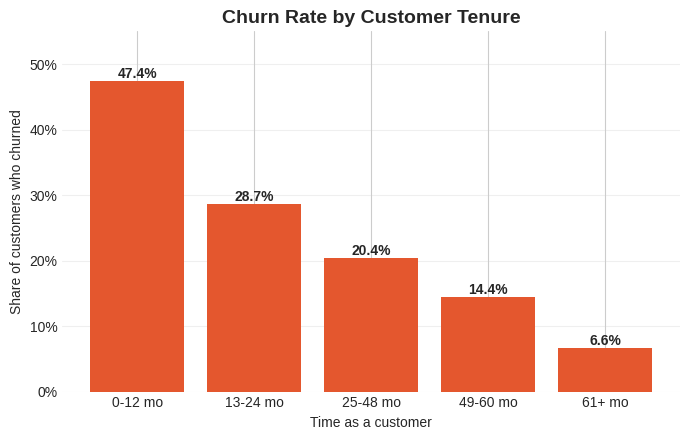

In [3]:
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn_flag'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(tenure_churn.index.astype(str), tenure_churn.values, color=COLOR_CHURN)
ax.set_title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of customers who churned')
ax.set_xlabel('Time as a customer')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.55)
for bar, val in zip(bars, tenure_churn.values):
    ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Finding 3 — Fiber optic customers churn more than twice as often as DSL customers

Despite being the premium internet product, **fiber optic customers churn at 41.9%**, versus **19.0%** for DSL and **7.4%** for customers with no internet service at all. This points to a specific problem with the fiber product — likely price or service reliability — rather than a general willingness to churn.

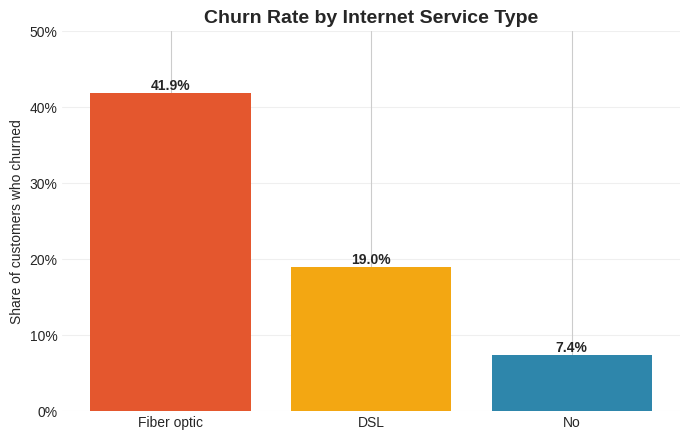

In [4]:
internet_churn = df.groupby('InternetService')['Churn_flag'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(internet_churn.index, internet_churn.values, color=[COLOR_CHURN, '#F3A712', COLOR_STAY])
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of customers who churned')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.5)
for bar, val in zip(bars, internet_churn.values):
    ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Finding 4 — Customers without protection add-ons churn nearly 3x more often

Customers without **Tech Support churn at 41.6%**, versus **15.2%** for those who have it. The pattern is nearly identical for **Online Security** (41.8% vs 14.6%). These add-ons appear to build loyalty, not just add revenue — likely because they increase how invested a customer feels, and reduce frustration that would otherwise push them to leave.

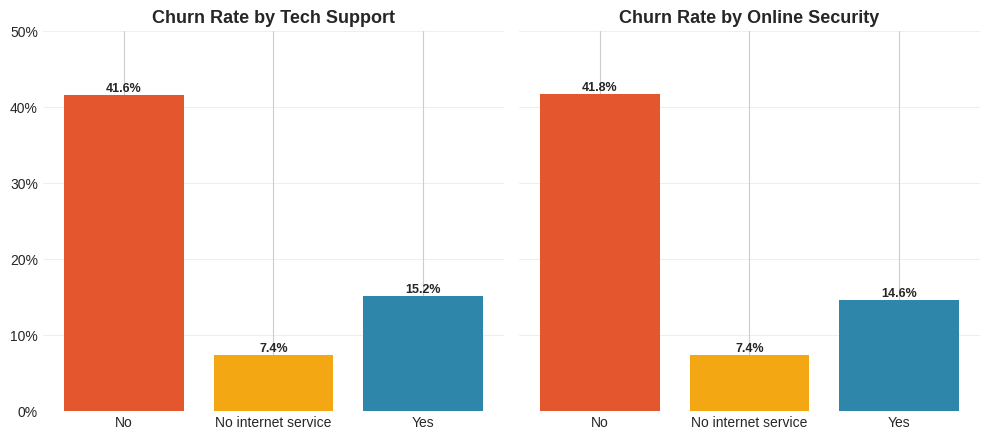

In [5]:
support_churn = df.groupby('TechSupport')['Churn_flag'].mean().reindex(['No', 'No internet service', 'Yes'])
security_churn = df.groupby('OnlineSecurity')['Churn_flag'].mean().reindex(['No', 'No internet service', 'Yes'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, data, title in zip(axes, [support_churn, security_churn], ['Tech Support', 'Online Security']):
    bars = ax.bar(data.index, data.values, color=[COLOR_CHURN, '#F3A712', COLOR_STAY])
    ax.set_title(f'Churn Rate by {title}', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0, 0.5)
    for bar, val in zip(bars, data.values):
        ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold', fontsize=9)
    sns.despine(left=True, bottom=True, ax=ax)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Finding 5 — Manual payment by electronic check is linked to much higher churn

Customers paying by **electronic check churn at 45.3%** — far higher than mailed check (19.1%), automatic bank transfer (16.7%), or automatic credit card (15.2%). Manual payment is often a signal of lower commitment, and the extra monthly friction of manually paying a bill may itself contribute to customers deciding to leave.

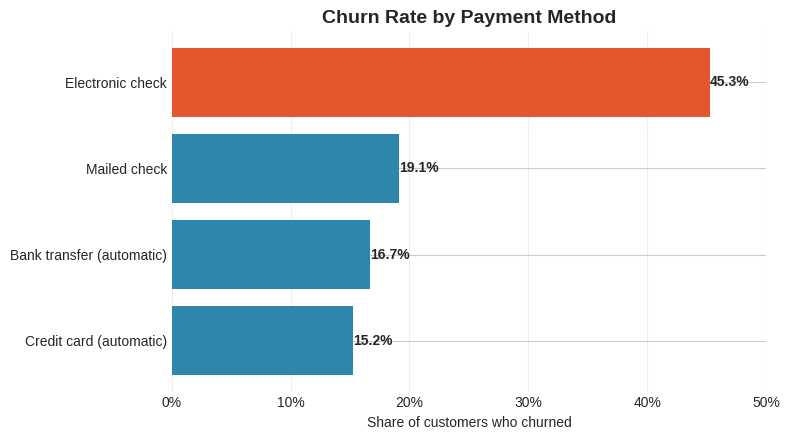

In [6]:
payment_churn = df.groupby('PaymentMethod')['Churn_flag'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [COLOR_CHURN if v == payment_churn.max() else COLOR_STAY for v in payment_churn.values]
bars = ax.barh(payment_churn.index, payment_churn.values, color=colors)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Share of customers who churned')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)
for bar, val in zip(bars, payment_churn.values):
    ax.annotate(f'{val:.1%}', (val, bar.get_y() + bar.get_height()/2), ha='left', va='center', fontweight='bold')
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Finding 6 (bonus) — Customers who churn are paying more, not less

Customers who churned paid **$74.44/month on average**, notably higher than the **$61.27/month** paid by customers who stayed. Combined with Finding 3, this suggests some churned customers may feel they're not getting enough value for a higher bill — particularly fiber customers.

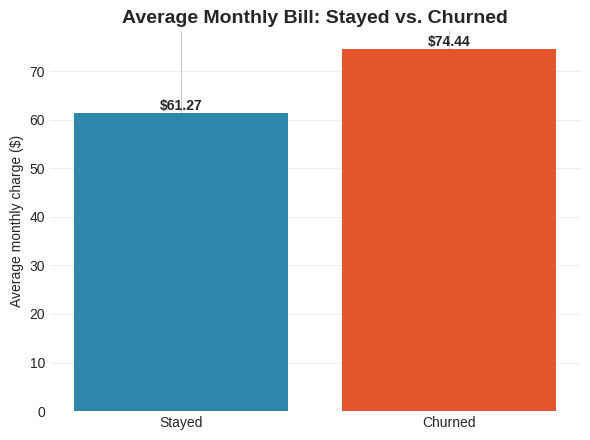

In [7]:
charges_by_churn = df.groupby('Churn')['MonthlyCharges'].mean().reindex(['No', 'Yes'])

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(['Stayed', 'Churned'], charges_by_churn.values, color=[COLOR_STAY, COLOR_CHURN])
ax.set_title('Average Monthly Bill: Stayed vs. Churned', fontsize=14, fontweight='bold')
ax.set_ylabel('Average monthly charge ($)')
for bar, val in zip(bars, charges_by_churn.values):
    ax.annotate(f'${val:.2f}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom', fontweight='bold')
sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Recommendations

1. **Incentivize longer contracts, especially in the first year.** Since month-to-month customers churn 15x more than two-year customers, and nearly half of all churn happens in year one, offer a meaningful discount or perk (e.g., a free month, waived installation fee) for new customers who commit to a one- or two-year contract at signup — when they're most likely to still be on a flexible plan.

2. **Investigate the fiber optic customer experience.** Fiber customers churn more than twice as often as DSL customers despite paying more. The business should audit fiber pricing versus competitors and reliability/support metrics for fiber customers specifically, since this looks like a product-level problem rather than a general churn tendency.

3. **Bundle a free trial of Tech Support and Online Security into new sign-ups.** Customers with these add-ons churn at roughly a third of the rate of those without. Offering a 3-6 month free trial (with an easy opt-out) could build the habit and stickiness these add-ons create, while giving the business a natural upsell moment once the trial ends.

4. **Nudge electronic-check customers toward automatic payment.** With electronic check customers churning at 45% vs ~15% for automatic payment methods, a small one-time incentive (e.g., a bill credit) to switch to autopay could reduce both payment friction and the churn associated with it.


---
## Appendix — Full Cleaning & Exploratory Analysis Code

*This section is for technical readers and reproduces the full data cleaning and analysis behind the findings above.*


In [8]:
# --- Data loading & cleaning ---
import pandas as pd

df_raw = pd.read_csv('Telco-Customer-Churn.csv')
print("Raw shape:", df_raw.shape)
print("\nMissing values per column:\n", df_raw.isnull().sum().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())

# TotalCharges is read as text because 11 brand-new customers have a blank value
# instead of 0. Convert to numeric and fill those blanks with 0.
blank_total_charges = df_raw[pd.to_numeric(df_raw['TotalCharges'], errors='coerce').isnull()]
print("\nRows with blank TotalCharges (all have tenure = 0):")
print(blank_total_charges[['tenure', 'MonthlyCharges', 'TotalCharges']])

df_clean = df_raw.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce').fillna(0)
df_clean['Churn_flag'] = (df_clean['Churn'] == 'Yes').astype(int)
print("\nOverall churn rate:", df_clean['Churn_flag'].mean())

Raw shape: (7043, 21)

Missing values per column:
 0

Duplicate rows: 0

Rows with blank TotalCharges (all have tenure = 0):
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             

Overall churn rate: 0.2653698707936959


In [9]:
# --- Full exploratory breakdown behind each finding ---
print("Churn rate by contract type:")
print(df_clean.groupby('Contract')['Churn_flag'].mean().sort_values(ascending=False), "\n")

print("Churn rate by tenure bucket:")
bins = [0, 12, 24, 48, 60, 100]
labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-60 mo', '61+ mo']
df_clean['tenure_bucket'] = pd.cut(df_clean['tenure'], bins=bins, labels=labels, include_lowest=True)
print(df_clean.groupby('tenure_bucket', observed=True)['Churn_flag'].mean(), "\n")

print("Churn rate by internet service:")
print(df_clean.groupby('InternetService')['Churn_flag'].mean().sort_values(ascending=False), "\n")

print("Churn rate by tech support:")
print(df_clean.groupby('TechSupport')['Churn_flag'].mean().sort_values(ascending=False), "\n")

print("Churn rate by online security:")
print(df_clean.groupby('OnlineSecurity')['Churn_flag'].mean().sort_values(ascending=False), "\n")

print("Churn rate by payment method:")
print(df_clean.groupby('PaymentMethod')['Churn_flag'].mean().sort_values(ascending=False), "\n")

print("Average monthly charges by churn status:")
print(df_clean.groupby('Churn')['MonthlyCharges'].mean(), "\n")

print("Churn rate by senior citizen status:")
print(df_clean.groupby('SeniorCitizen')['Churn_flag'].mean())

Churn rate by contract type:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_flag, dtype: float64 

Churn rate by tenure bucket:
tenure_bucket
0-12 mo     0.474382
13-24 mo    0.287109
25-48 mo    0.203890
49-60 mo    0.144231
61+ mo      0.066098
Name: Churn_flag, dtype: float64 

Churn rate by internet service:
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn_flag, dtype: float64 

Churn rate by tech support:
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Churn_flag, dtype: float64 

Churn rate by online security:
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn_flag, dtype: float64 

Churn rate by payment method:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Cr